# 1. Problem Statement

The objective of this project is to develop a predictive analytics model that estimates the future Customer Lifetime Value (CLV) of customers for an e-commerce business. Customer Lifetime Value represents the total revenue a business can expect from a customer throughout their relationship with the company.

Accurately predicting CLV helps businesses identify high-value customers, optimize marketing strategies, improve customer retention, and allocate resources more effectively. By analyzing customer demographics, purchasing behavior, engagement metrics, and transaction history, this project aims to build a regression model capable of predicting each customer's future lifetime value.

The project follows a complete predictive analytics workflow, including exploratory data analysis, data cleaning, feature engineering, model development, evaluation, and business insight generation.

# 2. Dataset Description

The dataset contains customer-level information collected from an e-commerce platform. Each row represents an individual customer and includes demographic details, purchasing behavior, customer engagement metrics, and service-related information.

The dataset consists of 25,625 customer records and 25 features, including the target variable Future_CLV, which represents the predicted future Customer Lifetime Value.

The features can be grouped into the following categories:

Customer Information: Customer ID, Name, Age, Gender, City, State
Membership Information: Membership Level and Acquisition Channel
Purchase Behavior: Total Orders, Total Spend, Average Order Value, Purchase Frequency, Total Items Purchased
Customer Engagement: Website Visits, App Sessions, Days Since Last Purchase
Customer Service: Return Rate, Support Tickets, Customer Satisfaction
Payment Information: Preferred Payment Method
Target Variable: Future_CLV

The objective is to predict the Future_CLV using the remaining customer-related features.

In [59]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [60]:
df = pd.read_csv(r"C:\Users\aswin\OneDrive\Desktop\Predictive-Analytics-Mini-Project\data\ecommerce_clv_dataset.csv")

df.head()

,Customer_ID,Customer_Name,Age,Gender,City,State,Membership_Level,Acquisition_Channel,Customer_Tenure_Days,Total_Orders,Total_Items_Purchased,Total_Spend,Average_Order_Value,Preferred_Category,Website_Visits,App_Sessions,Days_Since_Last_Purchase,Purchase_Frequency_Per_Month,Average_Days_Between_Orders,Coupon_Usage_Rate,Return_Rate,Support_Tickets,Customer_Satisfaction,Preferred_Payment_Method,Future_CLV
0,CUST100000,Madhuri Gupta,22.0,Female,Kolkata,West Bengal,Silver,Organic Search,331,2,3,1805.18,902.59,Sports & Fitness,37.0,27.0,335.0,0.181,168.73,0.478,0.535,3.0,3.27,Debit Card,200.00
1,CUST100001,Ritu Naidu,34.0,Other,Ahmedabad,Gujarat,Silver,Paid Ads,214,3,7,4518.55,1506.18,Home & Kitchen,31.0,20.0,145.0,0.421,67.69,0.392,0.428,2.0,3.64,Credit Card,325.56
2,CUST100002,Vidya Menon,37.0,Female,Hyderabad,Telangana,Silver,Email Marketing,1890,28,79,15672.76,559.74,Grocery,148.0,125.0,87.0,0.444,62.52,0.342,0.229,2.0,3.67,UPI,1201.04
3,CUST100003,Pankaj Pandey,29.0,Male,Delhi,Delhi,Silver,Organic Search,1170,20,37,14660.69,733.03,Fashion,98.0,61.0,27.0,0.513,68.20,0.278,0.421,4.0,3.34,UPI,747.54
4,CUST100004,Pooja Kumar,20.0,Female,Pune,Maharashtra,Silver,Organic Search,360,1,2,303.17,303.17,Electronics,115.0,92.0,398.0,0.083,323.45,0.112,0.266,4.0,3.94,Cash on Delivery,200.00


In [61]:
df.tail()

,Customer_ID,Customer_Name,Age,Gender,City,State,Membership_Level,Acquisition_Channel,Customer_Tenure_Days,Total_Orders,Total_Items_Purchased,Total_Spend,Average_Order_Value,Preferred_Category,Website_Visits,App_Sessions,Days_Since_Last_Purchase,Purchase_Frequency_Per_Month,Average_Days_Between_Orders,Coupon_Usage_Rate,Return_Rate,Support_Tickets,Customer_Satisfaction,Preferred_Payment_Method,Future_CLV
25620,CUST109114,Neha Pandey,27.0,Female,Ahmedabad,Gujarat,Gold,Paid Ads,761,13,33,9256.60,712.05,Electronics,220.0,175.0,9.0,0.512,55.74,0.335,0.226,2.0,4.02,UPI,1341.24
25621,CUST114433,Radhika Thakur,18.0,Female,Bhopal,Madhya Pradesh,Gold,Organic Search,180,3,7,2334.36,778.12,Home & Kitchen,75.0,35.0,74.0,0.500,59.95,0.907,0.194,3.0,4.06,UPI,200.00
25622,CUST108753,Pallavi Pandey,33.0,Female,Hyderabad,Telangana,Silver,Social Media,688,7,17,4247.36,606.77,Fashion,92.0,79.0,75.0,0.305,86.87,0.047,0.463,3.0,3.00,Credit Card,345.93
25623,CUST115547,Arjun Yadav,21.0,Male,Kochi,Kerala,Silver,Social Media,450,2,5,1162.37,581.18,Sports & Fitness,43.0,28.0,269.0,0.133,219.82,0.755,0.388,2.0,3.56,Debit Card,200.00
25624,CUST109372,Karan Bose,36.0,Male,Delhi,Delhi,Silver,Organic Search,578,5,13,2897.36,579.47,Fashion,57.0,42.0,49.0,0.260,137.48,0.582,0.494,1.0,3.14,UPI,284.38


In [62]:
df.sample(5, random_state=42)

,Customer_ID,Customer_Name,Age,Gender,City,State,Membership_Level,Acquisition_Channel,Customer_Tenure_Days,Total_Orders,Total_Items_Purchased,Total_Spend,Average_Order_Value,Preferred_Category,Website_Visits,App_Sessions,Days_Since_Last_Purchase,Purchase_Frequency_Per_Month,Average_Days_Between_Orders,Coupon_Usage_Rate,Return_Rate,Support_Tickets,Customer_Satisfaction,Preferred_Payment_Method,Future_CLV
10297,CUST110297,Manish Singh,37.0,Male,Ahmedabad,Gujarat,Silver,Social Media,819,6,13,3032.30,505.38,Home & Kitchen,79.0,54.0,88.0,0.220,168.88,0.788,0.348,6.0,4.16,UPI,249.93
14045,CUST114045,Siddharth Singh,51.0,Male,Chennai,Tamil Nadu,Platinum,social media,622,15,27,8158.40,543.89,Fashion,55.0,24.0,12.0,0.723,46.71,0.319,0.335,4.0,3.55,UPI,776.97
18337,CUST118337,Anil Verma,44.0,Male,Delhi,Delhi,Silver,Email Marketing,2520,23,44,18427.12,801.18,Beauty & Personal Care,319.0,274.0,160.0,0.274,130.95,0.306,0.191,0.0,4.14,Credit Card,1350.57
22666,CUST122666,Praveen Thakur,27.0,Male,Jaipur,Rajasthan,Platinum,Organic Search,490,7,24,6763.57,966.22,Electronics,96.0,57.0,98.0,0.429,74.26,0.575,0.210,4.0,3.88,Credit Card,798.31
3096,CUST103096,Radhika Bose,42.0,Female,NaN,Maharashtra,Silver,Organic Search,998,3,6,883.11,294.37,Fashion,24.0,15.0,64.0,0.090,283.54,0.520,0.176,0.0,4.24,UPI,200.00


In [63]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 25625
Number of Columns : 25


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25625 entries, 0 to 25624
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Customer_ID                   25625 non-null  str    
 1   Customer_Name                 25590 non-null  str    
 2   Age                           25591 non-null  float64
 3   Gender                        25584 non-null  str    
 4   City                          25583 non-null  str    
 5   State                         25598 non-null  str    
 6   Membership_Level              25589 non-null  str    
 7   Acquisition_Channel           25589 non-null  str    
 8   Customer_Tenure_Days          25625 non-null  int64  
 9   Total_Orders                  25625 non-null  int64  
 10  Total_Items_Purchased         25625 non-null  int64  
 11  Total_Spend                   25625 non-null  float64
 12  Average_Order_Value           25625 non-null  float64
 13  Preferred_Ca

In [65]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'str']).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Customer_Tenure_Days', 'Total_Orders', 'Total_Items_Purchased', 'Total_Spend', 'Average_Order_Value', 'Website_Visits', 'App_Sessions', 'Days_Since_Last_Purchase', 'Purchase_Frequency_Per_Month', 'Average_Days_Between_Orders', 'Coupon_Usage_Rate', 'Return_Rate', 'Support_Tickets', 'Customer_Satisfaction', 'Future_CLV']

Categorical Features:
['Customer_ID', 'Customer_Name', 'Gender', 'City', 'State', 'Membership_Level', 'Acquisition_Channel', 'Preferred_Category', 'Preferred_Payment_Method']


In [66]:
missing_values = df.isnull().sum()

missing_df = (
    pd.DataFrame({
        "Missing Values": missing_values,
        "Percentage": (missing_values / len(df)) * 100
    })
    .sort_values(by="Missing Values", ascending=False)
)

missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Percentage
Average_Days_Between_Orders,53,0.206829
Purchase_Frequency_Per_Month,43,0.167805
City,42,0.163902
Gender,41,0.160000
Return_Rate,39,0.152195
Membership_Level,36,0.140488
Acquisition_Channel,36,0.140488
Days_Since_Last_Purchase,35,0.136585
Customer_Name,35,0.136585
Preferred_Category,35,0.136585


In [67]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_count}")

Duplicate Rows: 625


In [68]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25591.0,32.657419,9.919393,15.00,26.000,32.0000,38.000,79.000
Customer_Tenure_Days,25625.0,966.680702,587.935012,15.00,524.000,900.0000,1350.000,3650.000
Total_Orders,25625.0,13.876722,14.216044,1.00,4.000,9.0000,19.000,155.000
Total_Items_Purchased,25625.0,31.771317,34.581599,1.00,9.000,21.0000,42.000,445.000
Total_Spend,25625.0,10452.529959,14897.566977,251.29,2237.180,5689.9300,12828.540,453410.700
Average_Order_Value,25625.0,700.125145,365.739038,213.59,444.260,616.8100,858.540,5333.230
Website_Visits,25593.0,139.557105,134.726458,2.00,50.000,99.0000,183.000,1722.000
App_Sessions,25601.0,90.651225,91.605669,1.00,31.000,63.0000,118.000,1410.000
Days_Since_Last_Purchase,25590.0,149.947987,188.312571,0.00,32.000,78.0000,182.000,900.000
Purchase_Frequency_Per_Month,25582.0,0.425699,0.300280,0.02,0.205,0.3525,0.564,3.228


In [69]:
df.describe(include='str').T

,count,unique,top,freq
Customer_ID,25625,25000,CUST100127,2
Customer_Name,25590,1800,Praveen Gupta,31
Gender,25584,14,Male,12883
City,25583,96,Delhi,2102
State,25598,58,Maharashtra,3317
Membership_Level,25589,18,Silver,12761
Acquisition_Channel,25589,38,Organic Search,6843
Preferred_Category,25590,43,Electronics,5607
Preferred_Payment_Method,25591,30,UPI,10409


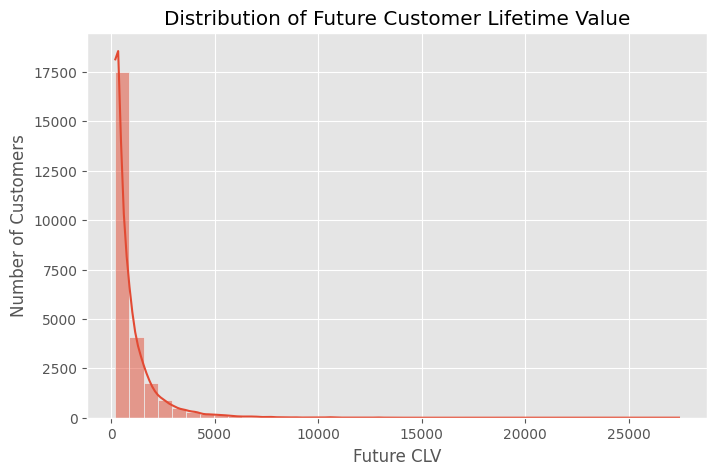

In [70]:
plt.figure(figsize=(8,5))

sns.histplot(df["Future_CLV"], bins=40, kde=True)

plt.title("Distribution of Future Customer Lifetime Value")
plt.xlabel("Future CLV")
plt.ylabel("Number of Customers")

plt.show()

The distribution of Future_CLV is highly right-skewed. Most customers have relatively low lifetime values, while a small number of customers contribute exceptionally high lifetime value. This pattern is common in e-commerce datasets, where a small proportion of loyal customers generate a significant share of total revenue.

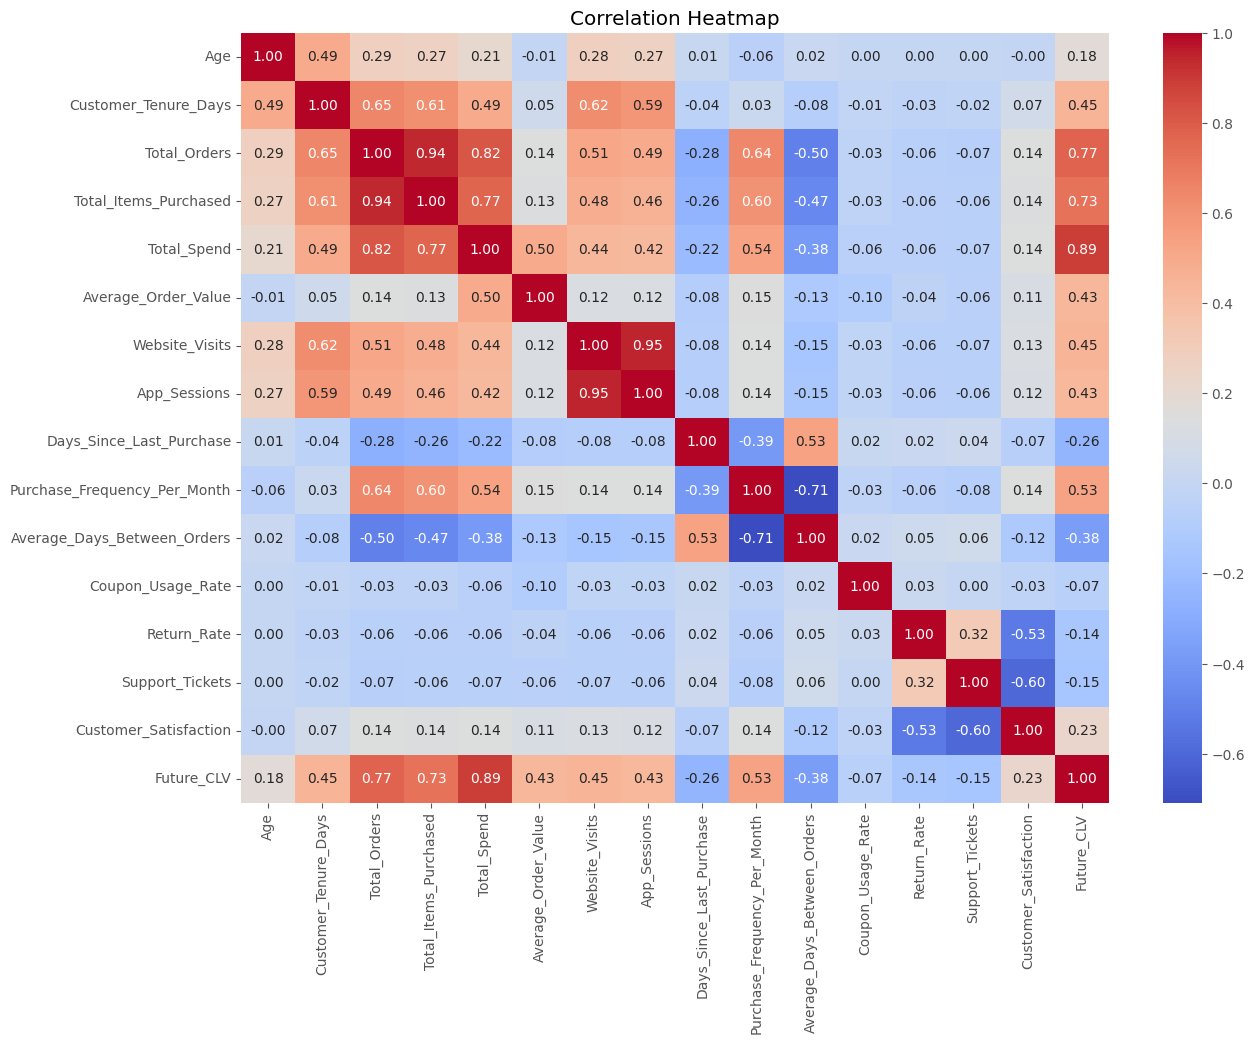

In [71]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df[numerical_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

The correlation analysis indicates that Total Spend, Total Orders, and Total Items Purchased have strong positive relationships with Future_CLV, suggesting that customers with higher purchasing activity tend to generate greater lifetime value. Conversely, longer intervals between purchases and a greater number of days since the last purchase are negatively associated with Future_CLV.

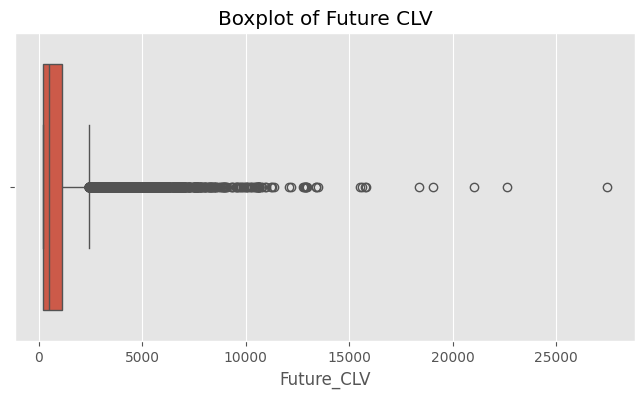

In [72]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Future_CLV"])

plt.title("Boxplot of Future CLV")

plt.show()

The boxplot reveals several high-value observations in the Future_CLV variable. These likely represent premium or highly loyal customers rather than data entry errors. Since such customers naturally exist in e-commerce businesses, these observations will not be removed unless further analysis identifies them as invalid.

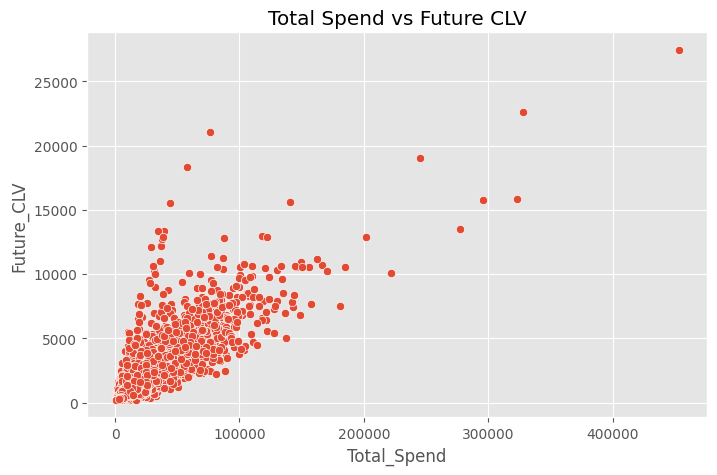

In [73]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Total_Spend",
    y="Future_CLV"
)

plt.title("Total Spend vs Future CLV")

plt.show()

The scatter plot demonstrates a clear positive relationship between Total Spend and Future_CLV. Customers with higher historical spending generally exhibit higher predicted lifetime value, making Total Spend a potentially important predictor during model development.

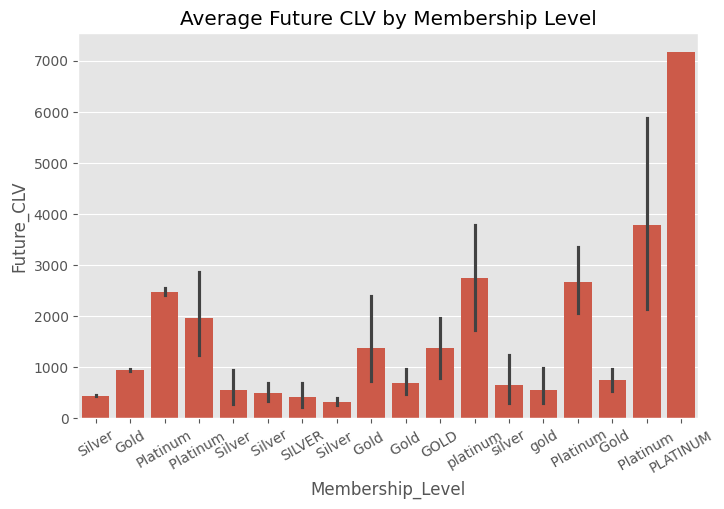

In [89]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Membership_Level",
    y="Future_CLV",
    estimator=np.mean
)

plt.title("Average Future CLV by Membership Level")

plt.xticks(rotation=30)

plt.show()

The average Future_CLV differs across membership levels. The presence of repeated membership categories with different letter cases indicates inconsistent categorical values in the raw dataset. These inconsistencies will be corrected during the data cleaning phase before model development.

# Key Findings from Exploratory Data Analysis
1. The dataset contains 25,625 customer records and 25 features.
2. Both numerical and categorical variables are present.
3. Missing values exist in multiple columns but account for a very small percentage of the dataset.
4. A total of 625 duplicate records were identified.
5. The target variable, Future_CLV, exhibits a right-skewed distribution with a small number of high-value customers.
6. Purchasing behavior features such as Total Spend, Total Orders, and Total Items Purchased show strong positive correlations with Future_CLV.
7. Inconsistent categorical values are visible in certain columns, indicating that data cleaning is necessary before modeling.

# 4. Data Cleaning & Preprocessing

Real-world datasets often contain missing values, duplicate records, inconsistent formatting, and incorrect data types. These issues can negatively affect exploratory analysis and machine learning models.

In this section, the dataset is cleaned by identifying and handling missing values, removing duplicate records, correcting inconsistent categorical values, and verifying appropriate data types. These preprocessing steps help ensure the data is accurate, consistent, and suitable for predictive modeling.

In [75]:
df_clean = df.copy()

In [76]:
missing_df = (
    pd.DataFrame({
        "Missing Values": df_clean.isnull().sum(),
        "Percentage": (df_clean.isnull().sum() / len(df_clean)) * 100
    })
    .sort_values(by="Missing Values", ascending=False)
)

missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Percentage
Average_Days_Between_Orders,53,0.206829
Purchase_Frequency_Per_Month,43,0.167805
City,42,0.163902
Gender,41,0.160000
Return_Rate,39,0.152195
Membership_Level,36,0.140488
Acquisition_Channel,36,0.140488
Days_Since_Last_Purchase,35,0.136585
Customer_Name,35,0.136585
Preferred_Category,35,0.136585


### Missing Values

The dataset contains a small number of missing values distributed across several numerical and categorical features. Since the proportion of missing values is less than 1% for every affected column, imputation is preferred over removing records to preserve valuable customer information.

In [77]:
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [78]:
categorical_columns = df_clean.select_dtypes(include=["object", "str"]).columns

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [79]:
df_clean.isnull().sum()

Customer_ID                     0
Customer_Name                   0
Age                             0
Gender                          0
City                            0
State                           0
Membership_Level                0
Acquisition_Channel             0
Customer_Tenure_Days            0
Total_Orders                    0
Total_Items_Purchased           0
Total_Spend                     0
Average_Order_Value             0
Preferred_Category              0
Website_Visits                  0
App_Sessions                    0
Days_Since_Last_Purchase        0
Purchase_Frequency_Per_Month    0
Average_Days_Between_Orders     0
Coupon_Usage_Rate               0
Return_Rate                     0
Support_Tickets                 0
Customer_Satisfaction           0
Preferred_Payment_Method        0
Future_CLV                      0
dtype: int64

Missing values in numerical features were replaced using the median value, as it is less sensitive to skewed distributions and extreme values.

Missing values in categorical features were replaced using the mode, preserving the most frequently occurring category in each column.

In [80]:
print("Duplicate Rows:", df_clean.duplicated().sum())

Duplicate Rows: 625


In [81]:
df_clean.drop_duplicates(inplace=True)

print("Duplicate Rows After Cleaning:", df_clean.duplicated().sum())

Duplicate Rows After Cleaning: 0


Duplicate records were removed to ensure that each customer observation contributes only once to the analysis, reducing potential bias during model training.

In [82]:
df_clean.shape

(25000, 25)

In [83]:
for col in categorical_columns:
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(df_clean[col].unique())


Column: Customer_ID
<StringArray>
['CUST100000', 'CUST100001', 'CUST100002', 'CUST100003', 'CUST100004',
 'CUST100005', 'CUST100006', 'CUST100007', 'CUST100008', 'CUST100009',
 ...
 'CUST124990', 'CUST124991', 'CUST124992', 'CUST124993', 'CUST124994',
 'CUST124995', 'CUST124996', 'CUST124997', 'CUST124998', 'CUST124999']
Length: 25000, dtype: str

Column: Customer_Name
<StringArray>
[ 'Madhuri Gupta',     'Ritu Naidu',    'Vidya Menon',  'Pankaj Pandey',
    'Pooja Kumar',    'Varun Menon',   'Ganesh Verma',  'Pallavi Naidu',
 'Deepika Bansal',    'Kajal Kumar',
 ...
  'Ganesh Thakur',    'Sanjay Nair',      'Ritu Nair',  'Kavita Pillai',
  'Vidya Chauhan',     'Anil Menon',   'Divya Pandey',  'Nandini Patel',
 'Suresh Agarwal',   'Rahul Thakur']
Length: 1800, dtype: str

Column: Gender
<StringArray>
[  'Female',    'Other',     'Male',  ' Female',    ' Male',     'male',
   'FEMALE',   ' Male ',  'Female ',    'Male ', ' Female ',   'female',
  ' Other ',     'MALE']
Length: 14, dtyp

In [84]:
def clean_text(series):
    return (
        series
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
    )

In [85]:
text_columns = [
    "Gender",
    "City",
    "State",
    "Membership_Level",
    "Acquisition_Channel",
    "Preferred_Category"
]

for col in text_columns:
    df_clean[col] = clean_text(df_clean[col])

In [86]:
df_clean["Preferred_Payment_Method"] = (
    df_clean["Preferred_Payment_Method"]
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
)

In [87]:
payment_mapping = {
    "Upi": "UPI",
    "Emi": "EMI"
}

df_clean["Preferred_Payment_Method"] = (
    df_clean["Preferred_Payment_Method"]
        .replace(payment_mapping)
)

In [88]:
for col in categorical_columns:
    print(f"\n{col}")
    print(sorted(df_clean[col].unique()))


Customer_ID
['CUST100000', 'CUST100001', 'CUST100002', 'CUST100003', 'CUST100004', 'CUST100005', 'CUST100006', 'CUST100007', 'CUST100008', 'CUST100009', 'CUST100010', 'CUST100011', 'CUST100012', 'CUST100013', 'CUST100014', 'CUST100015', 'CUST100016', 'CUST100017', 'CUST100018', 'CUST100019', 'CUST100020', 'CUST100021', 'CUST100022', 'CUST100023', 'CUST100024', 'CUST100025', 'CUST100026', 'CUST100027', 'CUST100028', 'CUST100029', 'CUST100030', 'CUST100031', 'CUST100032', 'CUST100033', 'CUST100034', 'CUST100035', 'CUST100036', 'CUST100037', 'CUST100038', 'CUST100039', 'CUST100040', 'CUST100041', 'CUST100042', 'CUST100043', 'CUST100044', 'CUST100045', 'CUST100046', 'CUST100047', 'CUST100048', 'CUST100049', 'CUST100050', 'CUST100051', 'CUST100052', 'CUST100053', 'CUST100054', 'CUST100055', 'CUST100056', 'CUST100057', 'CUST100058', 'CUST100059', 'CUST100060', 'CUST100061', 'CUST100062', 'CUST100063', 'CUST100064', 'CUST100065', 'CUST100066', 'CUST100067', 'CUST100068', 'CUST100069', 'CUST1

In [91]:
df_clean.dtypes

Customer_ID                         str
Customer_Name                       str
Age                             float64
Gender                              str
City                                str
State                               str
Membership_Level                    str
Acquisition_Channel                 str
Customer_Tenure_Days              int64
Total_Orders                      int64
Total_Items_Purchased             int64
Total_Spend                     float64
Average_Order_Value             float64
Preferred_Category                  str
Website_Visits                  float64
App_Sessions                    float64
Days_Since_Last_Purchase        float64
Purchase_Frequency_Per_Month    float64
Average_Days_Between_Orders     float64
Coupon_Usage_Rate               float64
Return_Rate                     float64
Support_Tickets                 float64
Customer_Satisfaction           float64
Preferred_Payment_Method            str
Future_CLV                      float64


## Issues Identified in the Dataset

The exploratory analysis revealed several data quality issues that required preprocessing before model development.

The following issues were identified:

- Missing values were present in multiple numerical and categorical features.
- The dataset contained 625 duplicate records.
- Several categorical columns contained inconsistent formatting, including:
  - Leading and trailing spaces
  - Mixed letter casing (uppercase, lowercase, title case)
  - Multiple spaces between words
- The data types of all features were reviewed and found to be appropriate for analysis.

## Cleaning Decisions

The following preprocessing steps were performed:

- Missing numerical values were replaced using the median of each feature.
- Missing categorical values were replaced using the mode of each feature.
- Duplicate records were removed to prevent repeated customer observations from influencing the analysis.
- Text inconsistencies were corrected by:
  - Removing leading and trailing spaces
  - Replacing multiple spaces with a single space
  - Standardizing text formatting
- Payment method abbreviations such as UPI and EMI were preserved after standardization.
- Data types were verified and no further conversions were required.

## Assumptions Made During Preprocessing

The following assumptions were made during preprocessing:

- Missing values were assumed to be random and therefore suitable for imputation instead of removing customer records.
- Duplicate rows were considered unintentional repetitions and were removed.
- Differences in capitalization and spacing within categorical variables were treated as formatting inconsistencies rather than different categories.
- Existing numerical and categorical data types were considered appropriate for the remaining stages of the project.

# 5. Feature Engineering

Feature engineering is the process of creating new variables from existing features to better capture customer behavior and improve predictive model performance.

The engineered features created in this project are based on business understanding of customer purchasing patterns and engagement. Each feature is evaluated to determine its relationship with the target variable, **Future_CLV**.

In [100]:
df_clean["Purchase_Intensity"] = (
    df_clean["Total_Orders"] / df_clean["Customer_Tenure_Days"]
)

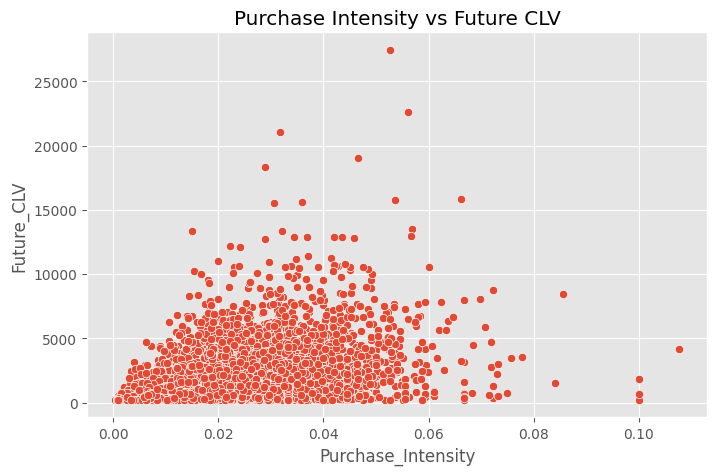

In [101]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x="Purchase_Intensity",
    y="Future_CLV"
)

plt.title("Purchase Intensity vs Future CLV")

plt.show()

### Feature 1: Purchase Intensity

Purchase Intensity was created by dividing the total number of orders by the customer's tenure in days.

This feature represents how frequently a customer places orders over the course of their relationship with the business. Customers who purchase more frequently are generally expected to have a higher lifetime value.

The feature showed a moderate positive relationship with Future_CLV, indicating that customers with higher purchase intensity tend to generate greater future lifetime value.

In [95]:
df_clean["Engagement_Score"] = (
    df_clean["Website_Visits"] + df_clean["App_Sessions"]
)

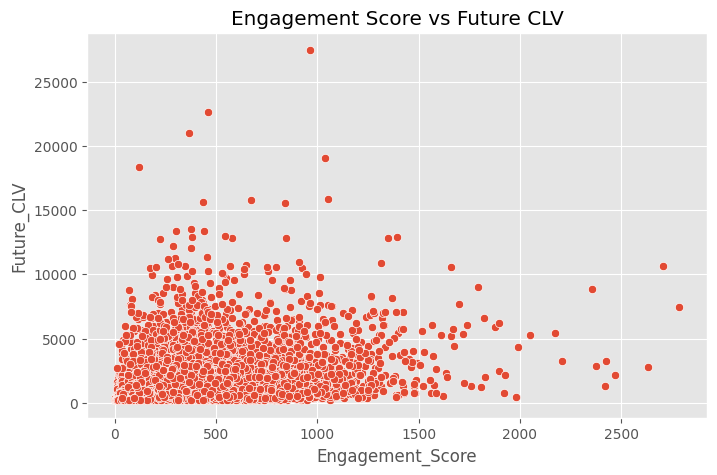

In [96]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x="Engagement_Score",
    y="Future_CLV"
)

plt.title("Engagement Score vs Future CLV")

plt.show()

### Feature 2: Engagement Score

Engagement Score was created by combining website visits and application sessions.

This feature estimates the overall level of customer interaction with the e-commerce platform. Higher engagement often reflects greater customer interest and a higher likelihood of future purchases.

The feature demonstrated a moderate positive relationship with Future_CLV.

In [97]:
df_clean["Spend_Per_Day"] = (
    df_clean["Total_Spend"] / df_clean["Customer_Tenure_Days"]
)

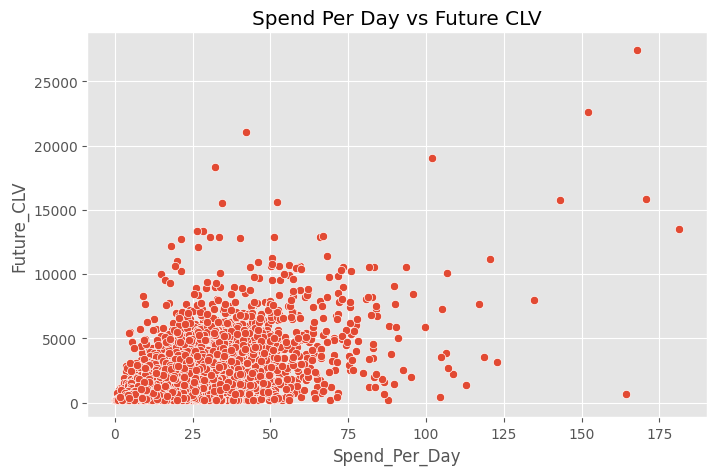

In [98]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x="Spend_Per_Day",
    y="Future_CLV"
)

plt.title("Spend Per Day vs Future CLV")

plt.show()

### Feature 3: Spend Per Day

Spend Per Day was calculated by dividing the customer's total spending by their tenure in days.

This feature measures the average rate at which a customer generates revenue over time. Customers with higher daily spending rates are more likely to contribute greater lifetime value.

Among the engineered features, Spend Per Day exhibited the strongest positive relationship with Future_CLV.

In [107]:
engineered_features = [
    "Purchase_Intensity",
    "Engagement_Score",
    "Spend_Per_Day",
    "Future_CLV"
]

df_clean[engineered_features].corr()[["Future_CLV"]]

,Future_CLV
Purchase_Intensity,0.529937
Engagement_Score,0.443173
Spend_Per_Day,0.686015
Future_CLV,1.000000


## Feature Engineering Summary

Three new features were engineered using existing customer purchasing and engagement information.

Correlation analysis showed that all three selected features had positive relationships with the target variable. Spend Per Day demonstrated the strongest relationship with Future_CLV, followed by Purchase Intensity and Engagement Score.

These engineered features will be included in the predictive modeling stage to evaluate whether they improve model performance.